# The Fourth Circle: Neural Networks, Part Three 
## Recurrent Neural Networks III: Bidirectional Recurrent Neural Networks

<br/>
Jiří Fejlek

2026-03-23
<br/>

## Table of Contents


- [IMDb dataset](#imdb)
- [Bidirectional Recurrent Neural Networks](#bidirect)
    - [Computations inside Bidirectional RNN Step by Step](#stepbystep)
    - [Training Bidirectional RNNs](#rnn_train)
    - [Training Bidirectional RNNs with a Pre-trained Word Embedding](#word_emb)
- [References](#references)

Up to this point, we considered only RNNs that processed sequences in one direction. For some tasks, such as predicting the value of the next element in the time series, this makes perfect sense. In other tasks, however, this may not be as clear-cut. Consider the *sentiment analysis*, which is essentially a classification task; the goal is to assess whether a given piece of text is of positive tone or negative (or neutral). It is not entirely clear whether it is always best to process texts in a single direction. Hence, why not consider both directions at the same time instead?

## IMDb dataset <a class="anchor" id="imdb"></a>

As we have hinted in the introduction, our task will be the sentiment analysis. In particular, we will use the IMDb dataset (https://ai.stanford.edu/~amaas/data/sentiment/) [[1](#1)], which consists of 50,000 (25,000 in the training set, 25,000 in the test set) polarized movie reviews (i.e.,  either clearly positive or clearly negative). 

We first need to read and tokenize the review texts. For simplicity's sake, we remove punctuation marks and capitalization. Then, we tokenize the reviews by individual words. Overall, the implementation is based on the one in [[2](#2)], and it closely follows the class *TimeMachine* from our previous project.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F

import re
import collections
import os

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

In [3]:
class Vocabulary: 

    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        
        # Flatten the list of tokens
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        
        # Count token frequencies
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse = True)

        # The list of unique tokens, we ignore tokens with frequency lower than min_freq
        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [token for token, freq in self.token_freqs if freq >= min_freq]))) 
        # convert tokens to indices
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
     
    def __len__(self):
        return len(self.idx_to_token)
    
    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk) # return unknown token if not in the vocabulary
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]
    
    @property
    def unk(self): # index for the unknown token
        return self.token_to_idx['<unk>']

In [4]:
class IMDb:
    
    def _read(self, is_train):

        data_dir = self.data_dir
                
        reviews, labels = [], []
        for label in ('pos', 'neg'):
            folder_name = os.path.join(data_dir, 'train' if is_train else 'test', label)
            for file in os.listdir(folder_name):
                with open(os.path.join(folder_name, file), 'rb') as f:
                    review = re.sub('[^A-Za-z]+', ' ',(f.read().decode('utf-8').replace('\n', ''))).lower()
                    reviews.append(review)
                    labels.append(1 if label == 'pos' else 0)
        return reviews, labels

    def _tokenize(self, text): # convert text to a list of words
        return [line.split() for line in text]

    def _build(self, is_train, vocab = None): # built vocabulary

        data_dir = self.data_dir
        reviews, labels = self._read(is_train)
        tokens = self._tokenize(reviews)
        
        if vocab is None: 
            vocab = Vocabulary(tokens, min_freq = 5, reserved_tokens= ['<pad>'])
        corpus = [vocab[token] for token in tokens]
        return corpus, labels, vocab

    def __init__(self, data_dir):  
        
        self.data_dir = data_dir
        
        self.train_corpus, self.train_labels, self.vocab = self._build(is_train = True) 
        self.test_corpus, self.test_labels, _ = self._build(is_train = False, vocab = self.vocab) 

Let us test the tokenization. 

In [5]:
IMDb_dataset = IMDb(data_dir = 'D:/nine circles 2/aclImdb')

In [6]:
IMDb_dataset.vocab.to_tokens(IMDb_dataset.train_corpus[0])[:10]

['bromwell', 'high', 'is', 'a', 'cartoon', 'comedy', 'it', 'ran', 'at', 'the']

In [7]:
IMDb_dataset.vocab.to_tokens(IMDb_dataset.test_corpus[0])[:10]

['i', 'went', 'and', 'saw', 'this', 'movie', 'last', 'night', 'after', 'being']

One important thing to notice is that reviews have varying lengths; i.e., the resulting sequences are also of varying lengths of elements.

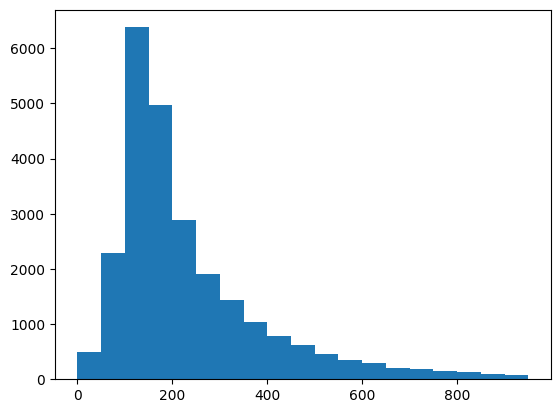

In [8]:
plt.hist([len(line) for line in IMDb_dataset.train_corpus], bins=range(0, 1000, 50));

To enable batch processing (and subsequent parallelization), we need to ensure that all sequences have the same length. Hence, we need to pick a fixed length (we will use 500 tokens) and crop or pad every sequence to this fixed length. We introduce a new special token *'\<pad\>'* to denote such padding. We will also add a new function, *truncate_pad*, that performs truncation/padding. 

Overall, we get the following implementation of the *IMDb* class. Notice that, since we handled the varying lengths of the sequences, we can also implement the dataloaders.

In [9]:
class IMDb:
    
    def _read(self, is_train):

        data_dir = self.data_dir
                
        reviews, labels = [], []
        for label in ('pos', 'neg'):
            folder_name = os.path.join(data_dir, 'train' if is_train else 'test', label)
            for file in os.listdir(folder_name):
                with open(os.path.join(folder_name, file), 'rb') as f:
                    review = re.sub('[^A-Za-z]+', ' ',(f.read().decode('utf-8').replace('\n', ''))).lower()
                    reviews.append(review)
                    labels.append(1 if label == 'pos' else 0)
        return reviews, labels

    def _tokenize(self, text): # convert text to a list of words
        return [line.split() for line in text]


    def truncate_pad(self, line, num_steps, padding_token):
        if len(line) > num_steps:
            return line[:num_steps]  # Truncate
        return line + [padding_token] * (num_steps - len(line))  # Pad

    def _build(self, is_train, vocab = None): # built vocabulary

        data_dir = self.data_dir
        reviews, labels = self._read(is_train)
        tokens = self._tokenize(reviews)
        
        if vocab is None: 
            vocab = Vocabulary(tokens, min_freq = 5, reserved_tokens= ['<pad>'])
            
        corpus = [vocab[token] for token in tokens]
        corpus = [self.truncate_pad(line, 500, vocab['<pad>']) for line in corpus]
        
        return corpus, labels, vocab

    def __init__(self, data_dir, batch_size, vocab = None):  
        
        self.data_dir = data_dir

        
        if vocab is None: 
            train_corpus, train_labels, self.vocab = self._build(is_train = True) 
        else:
            self.vocab = vocab
            train_corpus, train_labels, _  = self._build(is_train = True, vocab = self.vocab)    
            
        test_corpus, test_labels, _ = self._build(is_train = False, vocab = self.vocab)

        dataset_train = torch.utils.data.TensorDataset(*[torch.tensor(train_corpus), torch.tensor(train_labels)])
        dataset_test = torch.utils.data.TensorDataset(*[torch.tensor(test_corpus), torch.tensor(test_labels)])

        self.train_dataloader = torch.utils.data.DataLoader(dataset_train, batch_size, shuffle = True)
        self.test_dataloader = torch.utils.data.DataLoader(dataset_test, batch_size, shuffle = False)  

In [10]:
IMDb_dataset = IMDb(data_dir = 'D:/nine circles 2/aclImdb', batch_size = 250)

In [11]:
for X, Y in IMDb_dataset.train_dataloader:
    print('X:', X, '\nY:', Y)
    break

X: tensor([[12418,  3585, 25201,  ...,     0,     0,     0],
        [    2, 10098, 17718,  ...,     0,     0,     0],
        [ 6723,  2204,     2,  ...,     0,     0,     0],
        ...,
        [25745, 16796, 13419,  ...,     0,     0,     0],
        [12418,  7420, 25201,  ..., 18400,  5579,  7924],
        [ 9547, 17719, 12418,  ...,     0,     0,     0]]) 
Y: tensor([1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1,
        1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0,
        0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
        1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
        1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
        1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 

We are now ready to implement a bidirectional RNN that classifies reviews into positive and negative categories.

## Bidirectional Recurrent Neural Networks <a class="anchor" id="bidirect"></a>

Recurrent neural networks that process sequential data in both directions are called *bidirectional* [[2](#2)], and the concept is actually quite straightforward: a bidirectional RNN consists of two independent one-directional RNN layers that process data in opposite directions. The output of these two RNNs can then be simply concatenated.

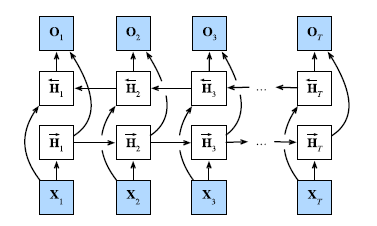

Hence, we get the following formulas for the hidden states 
$$ h_t^\rightarrow = \sigma (W_{xh}^\rightarrow x_t + W_{hh}^\rightarrow h_{t-1}^\rightarrow + b_h^\rightarrow ),$$
$$ h_t^\leftarrow = \sigma (W_{xh}^\leftarrow x_t + W_{hh}^\leftarrow h_{t+1}^\leftarrow + b_h^\leftarrow ),$$
where $W_{xh}^\rightarrow, W_{hh}^\rightarrow, W_{xh}^\leftarrow, W_{hh}^\leftarrow$ are weight matrices, and $b_h^\rightarrow$, $b_h^\leftarrow$ are biases. The final output is then given as
$$h_t = [h_t^\rightarrow, h_t^\leftarrow].$$

### Computations inside Bidirectional RNN Step by Step <a class="anchor" id="stepbystep"></a>

Before we move to the implementation itself, it will probably be more instructive to go through the computations step by step. As with our implementation of a simple RNN for token prediction, we need to implement three layers/blocks.  The first layer encodes tokens into vectors; the second layer is the recurrent layer itself. The last layer is a linear layer that transforms the recurrent layer's outputs into probability logits for classification.

Let us discuss the first layer a bit. In the previous two parts, we have used the standard one-hot encoding, which we first used way back for representing categorical features in linear regression. However, unlike categorial features in regression, which usually have just a few levels, the number of unique tokens in a vocabulary can easily reach tens to even hundreds of thousands.

In [12]:
IMDb_dataset.vocab.__len__()

28772

In this context, one-hot encoding is less than ideal due to its high dimensionality (each new category adds a new dimension to the input).  Hence, we will use *word embedding* [[2](#2)] to numerically encode tokens instead.  Similar to one-hot encoding, word embedding encodes tokens as vectors; however, unlike one-hot encoding, the dimensionality of the corresponding vector space is much lower than the number of tokens. Consequently, it is not possible to uniquely encode all tokens using merely standard basis vectors.

This alteration actually brings motivation for a further significant change. In one-hot encoding, all tokens are encoded as orthogonal unit vectors; there is no additional relation between the tokens expressed in this encoding. In word embeddings, token vectors are no longer orthogonal, i.e., some vectors may be more similar to each other than to other vectors (we measure the similarity using the dot product $\frac{\langle x \mid y\rangle}{\lVert x \rVert \lVert y \rVert }$, i.e., the cosine of the angle between them). We can use this measure of vector similarity to encode *semantic* similarity among various tokens.

The word embedding is implemented in PyTorch, similar to other neural network layers, as *nn.Embedding*. The values of these vector representations can then serve as additional parameters to be learned during training. Other than that, we also need to define a bidirectional recurrent layer *nn.RNN* (we need to specify that *bidirectional = True*) and a linear layer.

In [13]:
embed_size = 100
hidden_size = 64

embedding = nn.Embedding(IMDb_dataset.vocab.__len__(), embed_size)
rnn = nn.RNN(embed_size, hidden_size, num_layers = 1, bidirectional = True)
linear = nn.Linear(2*64, 2)

Let us go through the calculations during the forward pass. The original inputs $X$ are batched sequences of tokens and their labels $Y$. 

In [14]:
for X, Y in IMDb_dataset.train_dataloader:
    print('X:', X, '\nY:', Y)
    break

X: tensor([[15346,  6311, 21603,  ...,     0,     0,     0],
        [25975, 12480, 23730,  ...,     0,     0,     0],
        [17255,  2163, 11580,  ..., 25643, 28631, 27433],
        ...,
        [ 2208, 15205, 13419,  ...,     0,     0,     0],
        [27218,  9831,     1,  ...,     0,     0,     0],
        [25657, 14474, 10984,  ...,     0,     0,     0]]) 
Y: tensor([0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
        1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
        1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
        0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
        1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 

In [15]:
X.size()

torch.Size([250, 500])

In [16]:
Y.size()

torch.Size([250])

A word embedding represents each token as a vector of a prespecified dimensionality (in our case, *embed_size* $= 100$).

In [17]:
embeddings = embedding(X.T)
embeddings

tensor([[[ 1.2625e-01,  1.9090e+00,  1.9699e-01,  ...,  1.5136e-01,
           2.1141e+00,  9.7910e-01],
         [-1.8287e+00,  2.2392e-01,  2.3166e-01,  ..., -1.9111e-01,
          -3.8748e-01,  6.9791e-01],
         [-1.4593e-01,  8.1890e-01, -1.3386e-01,  ..., -1.4050e+00,
          -2.1039e+00,  5.9472e-01],
         ...,
         [ 9.8027e-01,  8.9138e-03, -1.9416e+00,  ..., -1.5936e+00,
          -6.2476e-01, -3.8299e-01],
         [ 2.5716e-01,  1.9035e+00, -4.2598e-02,  ..., -5.9801e-02,
           1.3801e+00, -1.3632e+00],
         [ 8.5123e-01,  7.5430e-01,  3.5562e-01,  ..., -1.3496e+00,
           7.6181e-01,  5.1776e-01]],

        [[ 1.2192e+00,  1.5561e-01,  1.8477e-01,  ..., -8.6827e-01,
           8.4997e-01,  1.4405e+00],
         [-4.7937e-01,  1.0699e+00,  2.0784e+00,  ...,  1.2453e+00,
           8.8741e-01,  7.4457e-01],
         [-3.4226e-01, -6.5940e-01,  1.9844e+00,  ...,  1.9162e-01,
          -4.0153e-03, -1.0944e+00],
         ...,
         [-1.7447e+00,  2

In [18]:
embeddings.size() # length x batch_size x embed_size 

torch.Size([500, 250, 100])

Next, we need to specify hidden states. As usual, the default hidden state's initial value is zero. We need to keep in mind that the number of hidden states is doubled, since we effectively initialize two RNNs.

In [19]:
hidden_state = torch.zeros((2, X.shape[0], hidden_size)) # initial hidden state: 2*num_layers x batch_size x num_hiddens
hidden_state.size()

torch.Size([2, 250, 64])

We can now evaluate the recurrent layer.

In [20]:
output, hidden_state_new = rnn(embeddings, hidden_state)

The new values of the hidden states naturally have the same dimensionality. The first matrix corresponds to the forward RNN, the second matrix corresponds to the backward RNN.

In [21]:
hidden_state_new.size()

torch.Size([2, 250, 64])

In [22]:
hidden_state_new[0]

tensor([[ 0.5553,  0.0425, -0.6742,  ..., -0.8579, -0.9579,  0.3482],
        [ 0.5553,  0.0425, -0.6742,  ..., -0.8579, -0.9579,  0.3482],
        [ 0.2084,  0.5778, -0.1347,  ..., -0.4822, -0.3001,  0.5971],
        ...,
        [ 0.5553,  0.0425, -0.6742,  ..., -0.8579, -0.9579,  0.3482],
        [ 0.5553,  0.0425, -0.6742,  ..., -0.8579, -0.9579,  0.3482],
        [ 0.5553,  0.0425, -0.6742,  ..., -0.8579, -0.9579,  0.3482]],
       grad_fn=<SelectBackward0>)

In [23]:
hidden_state_new[1]

tensor([[ 0.6853,  0.8594,  0.9257,  ..., -0.0458, -0.7275,  0.7560],
        [-0.0644, -0.6732, -0.6499,  ...,  0.6363, -0.4695, -0.8438],
        [-0.1758, -0.4792,  0.8491,  ...,  0.1808, -0.6539,  0.6280],
        ...,
        [ 0.0307, -0.6681, -0.0244,  ...,  0.4713,  0.7612, -0.0722],
        [-0.0536,  0.3024,  0.7099,  ..., -0.5925,  0.0593, -0.7461],
        [-0.7014,  0.1018, -0.4665,  ..., -0.3560, -0.7962, -0.4164]],
       grad_fn=<SelectBackward0>)

The output of the network has the following dimensionality (*length* x *batch_size* x 2*hidden_size*).

In [24]:
output.size()

torch.Size([500, 250, 128])

We can notice that the last values of the first half of the output correspond to the new hidden state of the forward RNN.

In [25]:
output[-1,:,0:hidden_size]

tensor([[ 0.5553,  0.0425, -0.6742,  ..., -0.8579, -0.9579,  0.3482],
        [ 0.5553,  0.0425, -0.6742,  ..., -0.8579, -0.9579,  0.3482],
        [ 0.2084,  0.5778, -0.1347,  ..., -0.4822, -0.3001,  0.5971],
        ...,
        [ 0.5553,  0.0425, -0.6742,  ..., -0.8579, -0.9579,  0.3482],
        [ 0.5553,  0.0425, -0.6742,  ..., -0.8579, -0.9579,  0.3482],
        [ 0.5553,  0.0425, -0.6742,  ..., -0.8579, -0.9579,  0.3482]],
       grad_fn=<SliceBackward0>)

Similarly, the first values of the latter half correspond to the new hidden state of the backward RNN. 

In [26]:
output[0,:,hidden_size:]

tensor([[ 0.6853,  0.8594,  0.9257,  ..., -0.0458, -0.7275,  0.7560],
        [-0.0644, -0.6732, -0.6499,  ...,  0.6363, -0.4695, -0.8438],
        [-0.1758, -0.4792,  0.8491,  ...,  0.1808, -0.6539,  0.6280],
        ...,
        [ 0.0307, -0.6681, -0.0244,  ...,  0.4713,  0.7612, -0.0722],
        [-0.0536,  0.3024,  0.7099,  ..., -0.5925,  0.0593, -0.7461],
        [-0.7014,  0.1018, -0.4665,  ..., -0.3560, -0.7962, -0.4164]],
       grad_fn=<SliceBackward0>)

Hence, the overall output is again the evolution of all hidden states, and they are in the order of the original sequence. Provided that we implemented a deep (multilayer) bidirectional RNN, the output would consist of the evolution of hidden states for the last recurrent layer.

In [27]:
torch.cat((output[-1,:,0:hidden_size], output[0,:,hidden_size:]), dim=1)

tensor([[ 0.5553,  0.0425, -0.6742,  ..., -0.0458, -0.7275,  0.7560],
        [ 0.5553,  0.0425, -0.6742,  ...,  0.6363, -0.4695, -0.8438],
        [ 0.2084,  0.5778, -0.1347,  ...,  0.1808, -0.6539,  0.6280],
        ...,
        [ 0.5553,  0.0425, -0.6742,  ...,  0.4713,  0.7612, -0.0722],
        [ 0.5553,  0.0425, -0.6742,  ..., -0.5925,  0.0593, -0.7461],
        [ 0.5553,  0.0425, -0.6742,  ..., -0.3560, -0.7962, -0.4164]],
       grad_fn=<CatBackward0>)

As the input for the linear, we will use the new values of the hidden states.

In [28]:
torch.cat((output[-1,:,0:hidden_size], output[0,:,hidden_size:]), dim=1).size()

torch.Size([250, 128])

In [29]:
linear(torch.cat((output[-1,:,0:hidden_size], output[0,:,hidden_size:]), dim=1))[0:10]

tensor([[-0.0561,  0.2886],
        [-0.3724,  0.3826],
        [-0.0663,  0.3117],
        [-0.0295,  0.4216],
        [ 0.2581,  0.2418],
        [-0.7786,  0.3086],
        [-0.2267,  0.5650],
        [-0.3261,  0.5191],
        [-0.1950,  0.3588],
        [-0.1791,  0.0220]], grad_fn=<SliceBackward0>)

Overall, we get the following implementation.

In [30]:
class RNN_Bidirect_Model(nn.Module):

    def __init__(self, hidden_size, num_layers, vocab_size, embed_size):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers, bidirectional = True)
        self.linear = nn.Linear(2*hidden_size, 2)

    def forward(self, inputs, state=None):
        
        if state is None:
            state = torch.zeros((2*self.num_layers, inputs.shape[0], self.hidden_size), device = inputs.device) # initial hidden state: 2*num_layers x batch_size x num_hiddens

        
        embeddings = self.embedding(inputs.T)
        Y, state = self.rnn(embeddings, state)
        Y = torch.cat((Y[-1,:,0:self.hidden_size], Y[0,:,self.hidden_size:]), dim=1)
        output = self.linear(Y)
        
        return output, state

In [31]:
rnn_bidirect_model = RNN_Bidirect_Model(hidden_size = 64, num_layers = 1, vocab_size = IMDb_dataset.vocab.__len__(), embed_size = 100)

In [32]:
rnn_bidirect_model(X)[0][0:10]

tensor([[-0.0794,  0.4616],
        [-0.3766,  0.2011],
        [-0.2019,  0.4427],
        [-0.1584,  0.0982],
        [ 0.1124,  0.0092],
        [ 0.0167, -0.0142],
        [-0.2380,  0.0882],
        [-0.2343,  0.2120],
        [ 0.0942, -0.1430],
        [-0.5039, -0.3197]], grad_fn=<SliceBackward0>)

### Training Bidirectional RNNs  <a class="anchor" id="rnn_train"></a>

First, let us train our simple bidirectional RNN on the IMDb dataset.

In [33]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler, max_norm):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits, _ = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = max_norm) # gradient clipping
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test, _ = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

In [34]:
torch.manual_seed(123)

# data loader
IMDb_dataset = IMDb(data_dir = 'D:/nine circles 2/aclImdb', batch_size = 250)
IMDb_train_loader = IMDb_dataset.train_dataloader
IMDb_test_loader = IMDb_dataset.test_dataloader

rnn_bidirect_cuda = RNN_Bidirect_Model(hidden_size = 256, num_layers = 1, vocab_size = IMDb_dataset.vocab.__len__(), embed_size = 100).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(rnn_bidirect_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.0005)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[50, 100], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()
max_norm = 10

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(IMDb_train_loader, IMDb_test_loader, rnn_bidirect_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

603.5498471260071


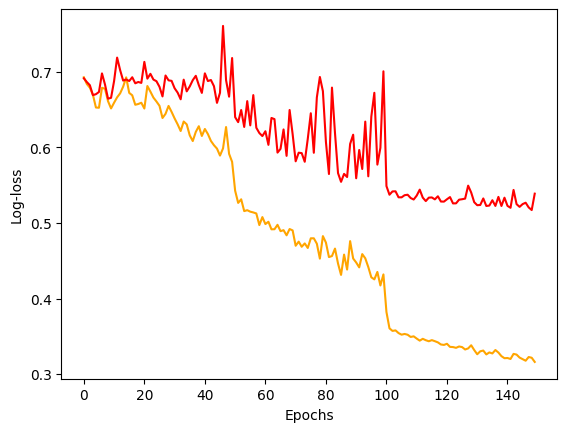

In [35]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

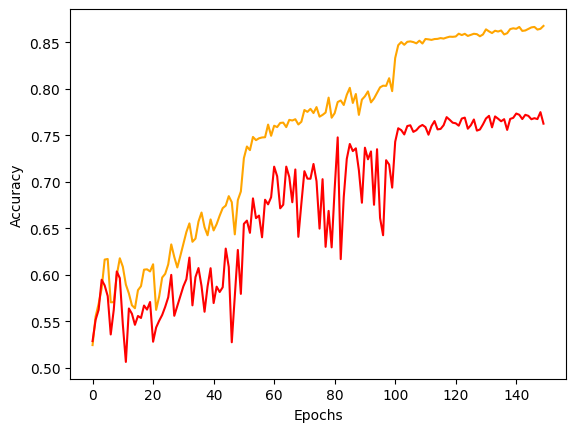

In [36]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

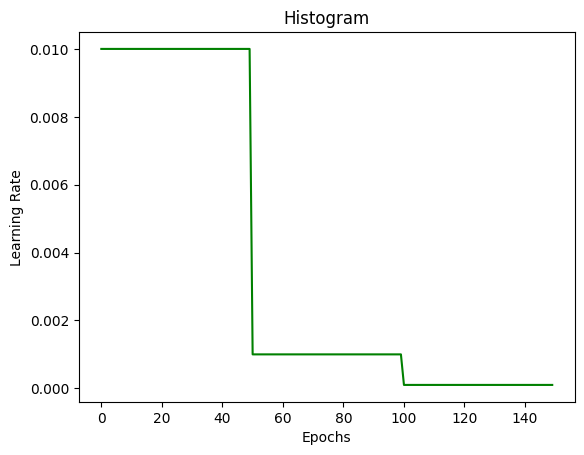

In [37]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [38]:
accu_epochs_train[149]

0.8674799799919128

In [39]:
accu_epochs_test[149]

0.7624399662017822

In [40]:
accu_epochs_test.max()

0.7748000025749207

We have achieved an accuracy of about 75%. Let us now use more sophisticated LSTM and GRU models to see whether we can do a bit better. Let us start with the bidirectional LSTM model.

In [41]:
del rnn_bidirect_cuda
torch.cuda.empty_cache()

In [42]:
class LSTM_Bidirect_Model(nn.Module):

    def __init__(self, hidden_size, num_layers, vocab_size, embed_size):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.LSTM(embed_size, hidden_size, num_layers, bidirectional = True)
        self.linear = nn.Linear(2*hidden_size, 2)

    def forward(self, inputs, hc_state=None):
        
        if hc_state is None:
            h_state = torch.zeros((2*self.num_layers, inputs.shape[0], self.hidden_size), device = inputs.device) # initial hidden state: 2*num_layers x batch_size x num_hiddens
            c_state = torch.zeros((2*self.num_layers, inputs.shape[0], self.hidden_size), device = inputs.device)
        else:
            h_state, c_state = hc_state

        
        embeddings = self.embedding(inputs.T)
        Y, (h_state, c_state) = self.rnn(embeddings, (h_state, c_state))
        Y = torch.cat((Y[-1,:,0:self.hidden_size], Y[0,:,self.hidden_size:]), dim=1)
        output = self.linear(Y)
        
        return output, (h_state, c_state)

In [43]:
torch.manual_seed(123)

# data loader
IMDb_dataset = IMDb(data_dir = 'D:/nine circles 2/aclImdb', batch_size = 250)
IMDb_train_loader = IMDb_dataset.train_dataloader
IMDb_test_loader = IMDb_dataset.test_dataloader

lstm_bidirect_cuda = LSTM_Bidirect_Model(hidden_size = 256, num_layers = 1, vocab_size = IMDb_dataset.vocab.__len__(), embed_size = 100).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(lstm_bidirect_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.0005)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[50, 100], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()
max_norm = 10

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(IMDb_train_loader, IMDb_test_loader, lstm_bidirect_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

1535.5622260570526


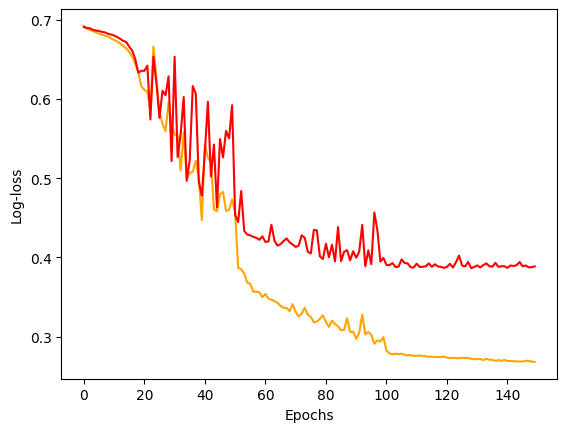

In [44]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

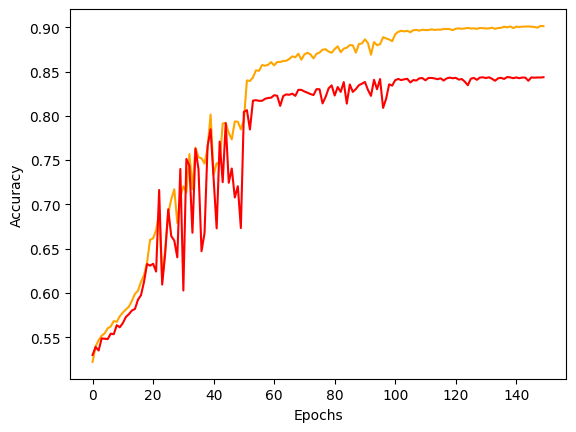

In [45]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

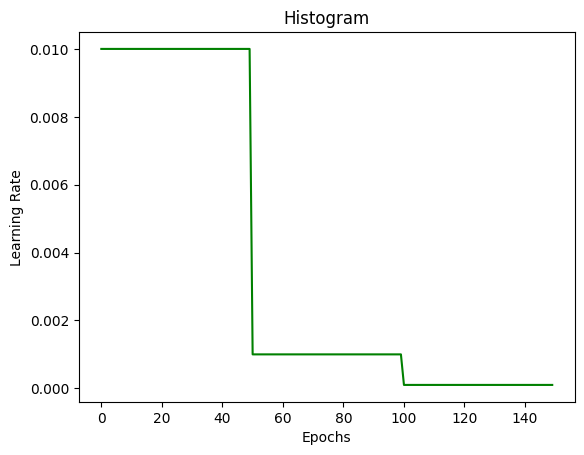

In [46]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [47]:
accu_epochs_train[149]

0.9012399911880493

In [48]:
accu_epochs_test[149]

0.8435999751091003

In [49]:
accu_epochs_test.max()

0.8437599539756775

Indeed, we have improved the accuracy by almost 10%. The GRU model is next.

In [50]:
del lstm_bidirect_cuda
torch.cuda.empty_cache()

In [51]:
class GRU_Bidirect_Model(nn.Module):

    def __init__(self, hidden_size, num_layers, vocab_size, embed_size):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, hidden_size, num_layers, bidirectional = True)
        self.linear = nn.Linear(2*hidden_size, 2)

    def forward(self, inputs, state=None):
        
        if state is None:
            state = torch.zeros((2*self.num_layers, inputs.shape[0], self.hidden_size), device = inputs.device) # initial hidden state: 2*num_layers x batch_size x num_hiddens

        
        embeddings = self.embedding(inputs.T)
        Y, state = self.rnn(embeddings, state)
        Y = torch.cat((Y[-1,:,0:self.hidden_size], Y[0,:,self.hidden_size:]), dim=1)
        output = self.linear(Y)
        
        return output, state

In [52]:
torch.manual_seed(123)

# data loader
IMDb_dataset = IMDb(data_dir = 'D:/nine circles 2/aclImdb', batch_size = 250)
IMDb_train_loader = IMDb_dataset.train_dataloader
IMDb_test_loader = IMDb_dataset.test_dataloader

gru_bidirect_cuda = GRU_Bidirect_Model(hidden_size = 256, num_layers = 1, vocab_size = IMDb_dataset.vocab.__len__(), embed_size = 100).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(gru_bidirect_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.0005)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[50, 100], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()
max_norm = 10

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(IMDb_train_loader, IMDb_test_loader, gru_bidirect_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

1549.9398839473724


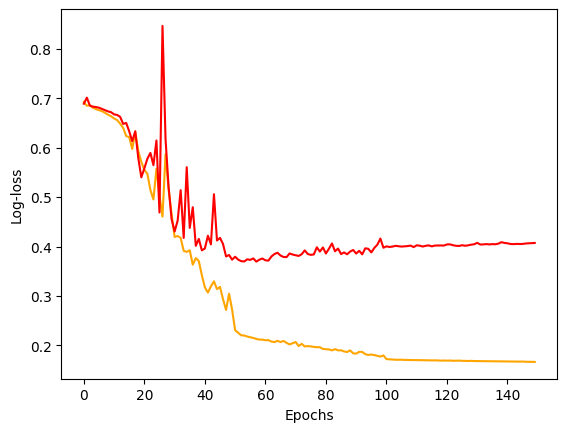

In [53]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

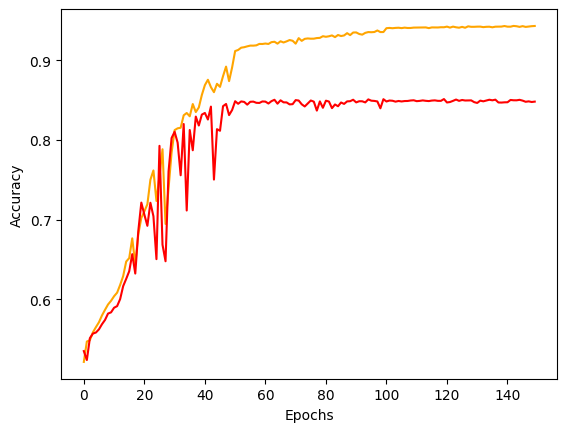

In [54]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

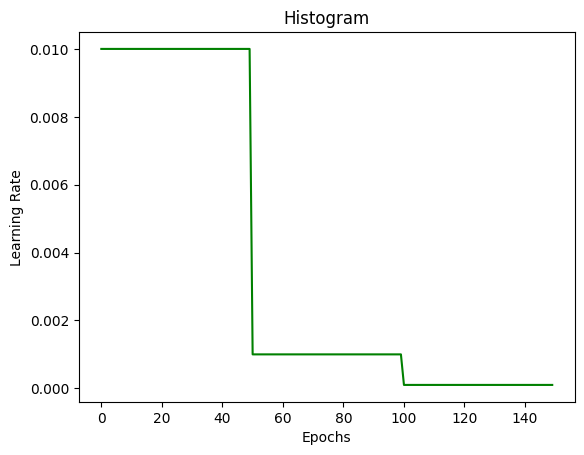

In [55]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [56]:
accu_epochs_train[149]

0.9432799816131592

In [57]:
accu_epochs_test[149]

0.8483200073242188

In [58]:
accu_epochs_test.max()

0.8515200018882751

In [59]:
del gru_bidirect_cuda
torch.cuda.empty_cache()

The GRU model's performance is very similar to that of the LSTM.

### Training Bidirectional RNNs with a Pre-trained Word Embedding <a class="anchor" id="word_emb"></a>

In the previous part, we learned a suitable word embedding during model training. However, we can often use pretrained word representations trained on much larger amounts of text data. To illustrate this approach, let us use word embedding based on the Global Vectors for Word Representation (GloVe) (https://nlp.stanford.edu/projects/glove/). Namely, we will use a 100d embedding trained on Wikipedia and Gigaword 5 (11.9B tokens).

We will discuss how to train these models later in its own circle dedicated specifically to natural language processing. For now, the key takeaway is that this model produces a list of tokens (mostly words and punctuation) along with their corresponding vector representations.

First, we need to read the file.

In [60]:
with open('D:/nine circles 2/wiki_giga_2024_100_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05.050_combined.txt','rt', encoding='utf-8') as GloVe_embd:
    GloVe_embd = GloVe_embd.read().strip().split('\n')

GloVe_vocab, GloVe_embeddings = [], []
for i in range(len(GloVe_embd)):
    i_word = GloVe_embd[i].split(' ')[0]
    i_embeddings = [float(val) for val in GloVe_embd[i].split(' ')[1:]]
    
    GloVe_vocab.append(i_word)
    GloVe_embeddings.append(i_embeddings)

The list consists of over one million tokens.

In [61]:
len(GloVe_vocab)

1291147

The list already contains a special token for unknown token *'\<unk\>'*. However, a padding token is not present. Hence, we need to add it to the list. We will use a vector of zeros for representation of this token.

In [62]:
GloVe_vocab[-1]

'<unk>'

In [63]:
GloVe_vocab.insert(0, '<pad>')

In [64]:
len(GloVe_vocab)

1291148

Overall, we get the following array of vector representations.

In [65]:
GloVe_embeddings = np.array(GloVe_embeddings)
pad_emb = np.zeros((1,GloVe_embeddings.shape[1]))

GloVe_embeddings = np.vstack((pad_emb,GloVe_embeddings))
GloVe_embeddings

array([[ 0.00000e+00,  0.00000e+00,  0.00000e+00, ...,  0.00000e+00,
         0.00000e+00,  0.00000e+00],
       [ 3.06717e-01, -3.20530e-01, -3.93647e-01, ...,  1.27164e-01,
        -2.98990e-02,  2.47113e-01],
       [ 2.25320e-02,  3.20788e-01, -2.95389e-01, ...,  1.55399e-01,
         3.24172e-01,  6.89770e-02],
       ...,
       [-1.84189e-01, -9.77450e-02,  1.30043e-01, ...,  2.00980e-02,
        -2.35256e-01, -5.64654e-01],
       [-1.48899e-01, -1.51066e-01,  3.28153e-01, ..., -1.58019e-01,
        -1.93719e-01,  2.34152e-01],
       [-1.55769e-01, -7.35950e-02,  2.12584e-01, ..., -2.80950e-02,
        -9.49010e-02,  4.11000e-04]])

Next, we need to convert our token representation of the IMDb dataset to our new GloVe token representation. Hence, we will implement a new class *Vocabulary_pretrained* that builds a vocabulary from the preexisting list of tokens.

In [66]:
class Vocabulary_pretrained: 

    def __init__(self, vocabulary_tokens):
        
        self.idx_to_token = vocabulary_tokens 
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
     
    def __len__(self):
        return len(self.idx_to_token)
    
    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk) # return unknown token if not in the vocabulary
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]
    
    @property
    def unk(self): # index for the unknown token
        return self.token_to_idx['<unk>']

Let us test that our new vocabulary works.

In [67]:
vocab_pretrained_GloVe = Vocabulary_pretrained(GloVe_vocab)

In [68]:
vocab_pretrained_GloVe['bromwell', 'high', 'is', 'a', 'cartoon', 'comedy', 'it', 'ran', 'at', 'the']

[182303, 154, 16, 8, 8000, 2699, 21, 1377, 23, 1]

The words from the IMDb dataset are then indexed using the prepared vocabulary rather than creating a vocabulary directly from the IMDb text.  

In [69]:
IMDb_dataset = IMDb(data_dir = 'D:/nine circles 2/aclImdb', batch_size = 250, vocab = vocab_pretrained_GloVe)

In [70]:
for X, Y in IMDb_dataset.train_dataloader:
    print('X:', X, '\nY:', Y)
    break

X: tensor([[   42,  5613,    37,  ...,     0,     0,     0],
        [   42,   808,    40,  ...,     0,     0,     0],
        [   42, 37092,    50,  ...,     0,     0,     0],
        ...,
        [   42,    15,    37,  ...,     0,     0,     0],
        [   42,   808,    40,  ...,     0,     0,     0],
        [   40,  1055,   194,  ...,     0,     0,     0]]) 
Y: tensor([0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
        0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1,
        1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
        0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 

In [71]:
IMDb_dataset.vocab.to_tokens(X[0])[:20]

['i',
 'shall',
 'not',
 'waste',
 'my',
 'time',
 'writing',
 'anything',
 'much',
 'further',
 'about',
 'how',
 'every',
 'aspect',
 'of',
 'this',
 'film',
 'is',
 'indescribably',
 'bad']

As the last step, we need to replace the weights in our embedding layer with the ones we have obtained from the GloVe embedding.

In [72]:
rnn_bidirect_model = RNN_Bidirect_Model(hidden_size = 64, num_layers = 1, vocab_size = IMDb_dataset.vocab.__len__(), embed_size = 100)

In [73]:
rnn_bidirect_model.embedding.weight

Parameter containing:
tensor([[ 0.0573, -0.9780, -0.4860,  ...,  0.4121,  0.5040, -0.1398],
        [-1.4361, -0.7195, -0.2983,  ..., -1.4791,  0.3663,  0.6766],
        [-0.5278, -0.4593,  1.5745,  ..., -1.1968,  1.5010,  0.2660],
        ...,
        [-0.0048,  1.1696, -0.9331,  ...,  0.1190,  0.7939,  0.3701],
        [-0.4184,  0.0287,  0.4493,  ..., -0.5172,  0.0570,  1.0906],
        [-0.6493,  0.0159, -0.2247,  ...,  1.4178, -1.5159, -0.1759]],
       requires_grad=True)

In [74]:
rnn_bidirect_model.embedding.weight.data.copy_(torch.from_numpy(GloVe_embeddings))

tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 3.0672e-01, -3.2053e-01, -3.9365e-01,  ...,  1.2716e-01,
         -2.9899e-02,  2.4711e-01],
        [ 2.2532e-02,  3.2079e-01, -2.9539e-01,  ...,  1.5540e-01,
          3.2417e-01,  6.8977e-02],
        ...,
        [-1.8419e-01, -9.7745e-02,  1.3004e-01,  ...,  2.0098e-02,
         -2.3526e-01, -5.6465e-01],
        [-1.4890e-01, -1.5107e-01,  3.2815e-01,  ..., -1.5802e-01,
         -1.9372e-01,  2.3415e-01],
        [-1.5577e-01, -7.3595e-02,  2.1258e-01,  ..., -2.8095e-02,
         -9.4901e-02,  4.1100e-04]])

We should not need to retrain these weights. Hence, we disable these weights from gradient computations, ensuring that these values remain fixed during the training loop.

In [75]:
rnn_bidirect_model.embedding.weight.requires_grad = False

We have prepared all the necessary pieces, and we can now train the model. Let us start with a simple bidirectional RNN model. 

In [76]:
torch.manual_seed(123)

# data loader
IMDb_dataset = IMDb(data_dir = 'D:/nine circles 2/aclImdb', batch_size = 250, vocab = vocab_pretrained_GloVe)
IMDb_train_loader = IMDb_dataset.train_dataloader
IMDb_test_loader = IMDb_dataset.test_dataloader

rnn_bidirect_cuda = RNN_Bidirect_Model(hidden_size = 256, num_layers = 1, vocab_size = IMDb_dataset.vocab.__len__(), embed_size = 100).to(cuda_device)
rnn_bidirect_cuda.embedding.weight.data.copy_(torch.from_numpy(GloVe_embeddings))
rnn_bidirect_cuda.embedding.weight.requires_grad = False

optim_SGD_cuda =  torch.optim.SGD(rnn_bidirect_cuda.parameters(), lr = 0.001, momentum = 0.9, weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[50, 100], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()
max_norm = 10

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(IMDb_train_loader, IMDb_test_loader, rnn_bidirect_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

506.0928068161011


In [77]:
rnn_bidirect_model.embedding.weight

Parameter containing:
tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 3.0672e-01, -3.2053e-01, -3.9365e-01,  ...,  1.2716e-01,
         -2.9899e-02,  2.4711e-01],
        [ 2.2532e-02,  3.2079e-01, -2.9539e-01,  ...,  1.5540e-01,
          3.2417e-01,  6.8977e-02],
        ...,
        [-1.8419e-01, -9.7745e-02,  1.3004e-01,  ...,  2.0098e-02,
         -2.3526e-01, -5.6465e-01],
        [-1.4890e-01, -1.5107e-01,  3.2815e-01,  ..., -1.5802e-01,
         -1.9372e-01,  2.3415e-01],
        [-1.5577e-01, -7.3595e-02,  2.1258e-01,  ..., -2.8095e-02,
         -9.4901e-02,  4.1100e-04]])

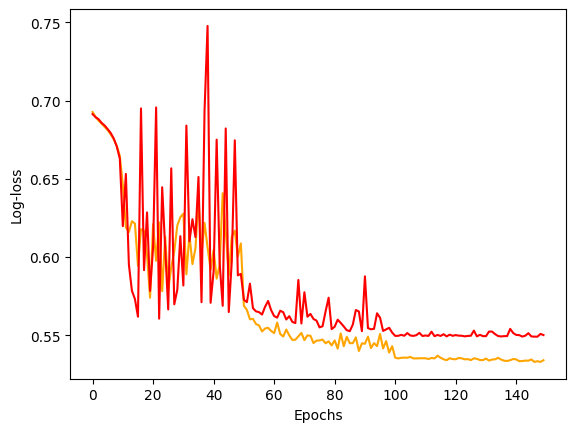

In [78]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

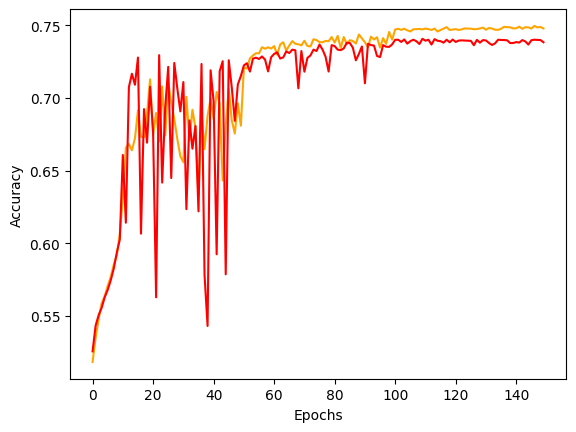

In [79]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

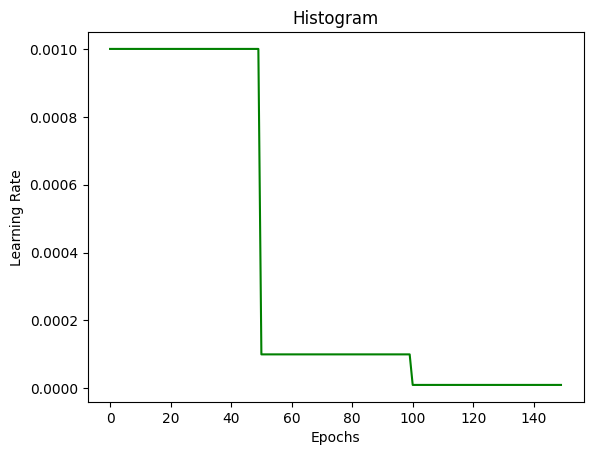

In [80]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [81]:
accu_epochs_train[149]

0.7478399872779846

In [82]:
accu_epochs_test[149]

0.738319993019104

In [83]:
accu_epochs_test.max()

0.7406799793243408

The classification accuracy did not change much. Let us test the LSTM and GRU models next.

In [84]:
del rnn_bidirect_cuda
torch.cuda.empty_cache()

In [85]:
torch.manual_seed(123)

# data loader
IMDb_dataset = IMDb(data_dir = 'D:/nine circles 2/aclImdb', batch_size = 250, vocab = vocab_pretrained_GloVe)
IMDb_train_loader = IMDb_dataset.train_dataloader
IMDb_test_loader = IMDb_dataset.test_dataloader

lstm_bidirect_cuda = LSTM_Bidirect_Model(hidden_size = 256, num_layers = 1, vocab_size = IMDb_dataset.vocab.__len__(), embed_size = 100).to(cuda_device)
lstm_bidirect_cuda.embedding.weight.data.copy_(torch.from_numpy(GloVe_embeddings))
lstm_bidirect_cuda.embedding.weight.requires_grad = False

optim_SGD_cuda =  torch.optim.SGD(lstm_bidirect_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[50, 100], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()
max_norm = 10

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(IMDb_train_loader, IMDb_test_loader, lstm_bidirect_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

1404.607479095459


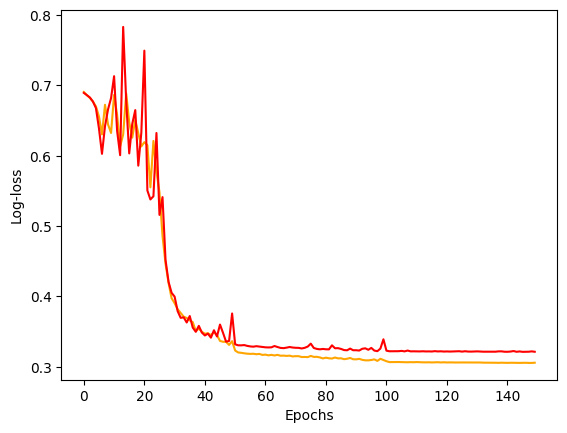

In [86]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

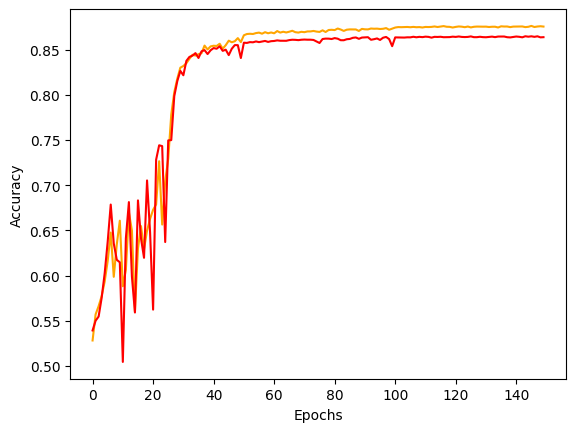

In [87]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

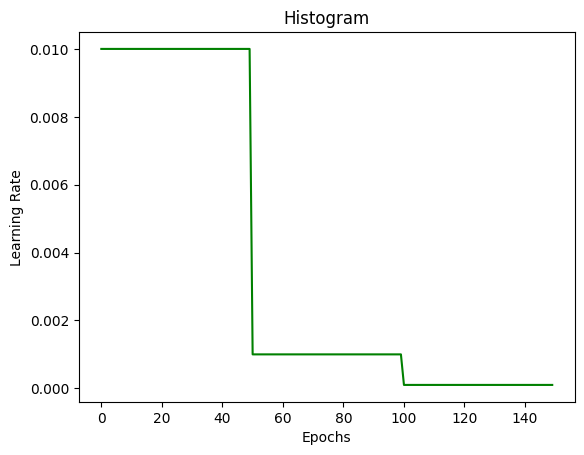

In [88]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [89]:
accu_epochs_train[149]

0.8753599524497986

In [90]:
accu_epochs_test[149]

0.8636399507522583

In [91]:
accu_epochs_test.max()

0.8646399974822998

The LSTM model's accuracy actually improved slightly by about 2%.

In [92]:
del lstm_bidirect_cuda
torch.cuda.empty_cache()

In [93]:
torch.manual_seed(123)

# data loader
IMDb_dataset = IMDb(data_dir = 'D:/nine circles 2/aclImdb', batch_size = 250, vocab = vocab_pretrained_GloVe)
IMDb_train_loader = IMDb_dataset.train_dataloader
IMDb_test_loader = IMDb_dataset.test_dataloader

gru_bidirect_cuda = GRU_Bidirect_Model(hidden_size = 256, num_layers = 1, vocab_size = IMDb_dataset.vocab.__len__(), embed_size = 100).to(cuda_device)
gru_bidirect_cuda.embedding.weight.data.copy_(torch.from_numpy(GloVe_embeddings))
gru_bidirect_cuda.embedding.weight.requires_grad = False

optim_SGD_cuda =  torch.optim.SGD(gru_bidirect_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[50, 100], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()
max_norm = 10

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(IMDb_train_loader, IMDb_test_loader, gru_bidirect_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

1514.654109954834


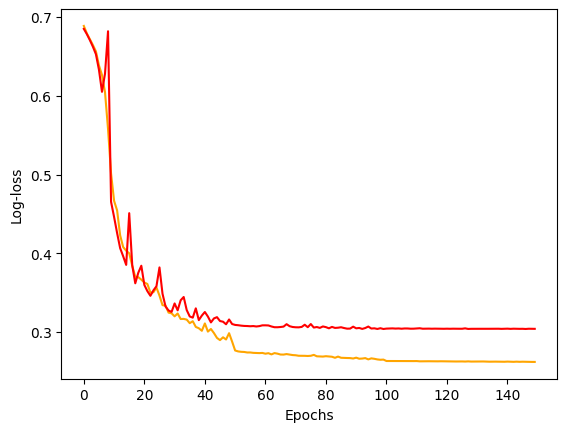

In [94]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

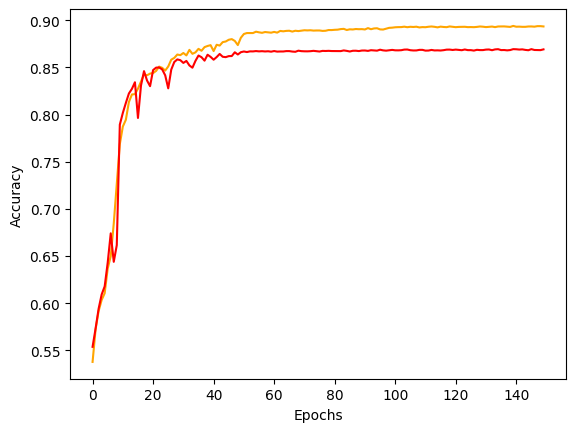

In [95]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

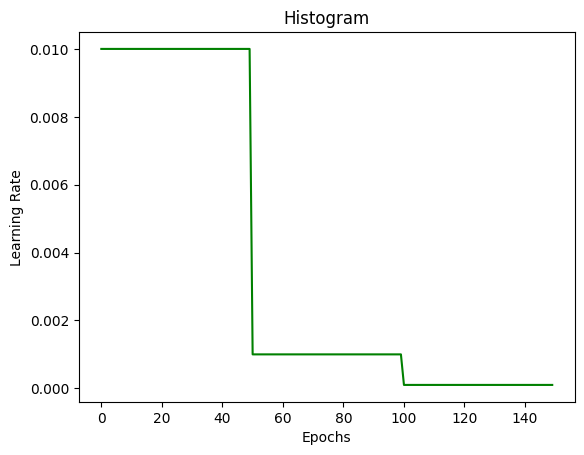

In [96]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [97]:
accu_epochs_train[149]

0.8935199975967407

In [98]:
accu_epochs_test[149]

0.8691999912261963

In [99]:
accu_epochs_test.max()

0.869439959526062

The GRU model is even better; we have achieved a classification accuracy of almost 87% percent. Overall, we observe that the pretrained word embedding not only simplified the training of our model, but it also improved our model a bit.

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> MAAS, Andrew, et al. Learning word vectors for sentiment analysis. In: *Proceedings of the 49th annual meeting of the association for computational linguistics: Human language technologies.* 2011. p. 142-150.

<a id="2">[2]</a> HOCHREITER, Sepp; SCHMIDHUBER, Jürgen. Long short-term memory. Neural computation, 1997, 9.8: 1735-1780.

<a id="3">[3]</a> ZHANG, Aston, et al. *Dive into deep learning*. Cambridge University Press, 2023.

<a id="4">[4]</a> PENNINGTON, Jeffrey; SOCHER, Richard; MANNING, Christopher D. Glove: Global vectors for word representation. In: *Proceedings of the 2014 conference on empirical methods in natural language processing (EMNLP).* 2014. p. 1532-1543.